In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

In [ ]:
!apt-get install -y ffmpeg libsndfile1
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

In [ ]:
api.dataset_download_files(
    "andradaolteanu/gtzan-dataset-music-genre-classification",
    path="/content/dataset",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification


In [ ]:
import os

os.listdir("/content/dataset/Data")

['features_3_sec.csv',
 'images_original',
 'features_30_sec.csv',
 'genres_original']

In [ ]:
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import numpy as np
import torch
import os
from torch.utils.data import Dataset


class GenreDataset(Dataset):

    def __init__(self, data_path, sr=22050, duration=3, augment=False):

        self.augment = augment
        self.data = []
        self.labels = []

        self.sr = sr
        self.samples = sr * duration

        genres = sorted(os.listdir(data_path))

        # label mapping
        self.genre_to_idx = {genre: i for i, genre in enumerate(genres)}
        self.idx_to_genre = {i: genre for genre, i in self.genre_to_idx.items()}

        for genre in genres:
            genre_folder = os.path.join(data_path, genre)

            for file in os.listdir(genre_folder):
                if file.endswith(".wav"):
                    file_path = os.path.join(genre_folder, file)
                    self.data.append(file_path)
                    self.labels.append(self.genre_to_idx[genre])

        # transforms
        self.mel_spectrogram_transform = T.MelSpectrogram(
            sample_rate=self.sr,
            n_fft=1024,
            hop_length=256,
            n_mels=128
        )

        self.amplitude_to_db_transform = T.AmplitudeToDB()

        # SpecAugment
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=35)

        self.resampler = T.Resample(orig_freq=self.sr, new_freq=self.sr)
        self.resamplers = {}


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):

        file_path = self.data[idx]
        label = self.labels[idx]

        try:
            audio, sr_original = torchaudio.load(file_path)

            # resample properly
            if sr_original != self.sr:

                if sr_original not in self.resamplers:
                    self.resamplers[sr_original] = T.Resample(sr_original, self.sr)

                audio = self.resamplers[sr_original](audio)
            # stereo → mono
            if audio.shape[0] > 1:
                audio = torch.mean(audio, dim=0, keepdim=True)

            # fixed length
            if audio.shape[1] > self.samples:
                audio = audio[:, :self.samples]
            else:
                padding = self.samples - audio.shape[1]
                audio = F.pad(audio, (0, padding))

            # waveform augmentation
            if self.augment:

                # time shift
                shift = np.random.randint(self.samples)
                audio = torch.roll(audio, shifts=shift, dims=1)

                # stronger noise
                audio += 0.005 * torch.randn_like(audio)

                # random gain
                gain = np.random.uniform(0.8, 1.2)
                audio = audio * gain

            # mel spectrogram
            mel = self.mel_spectrogram_transform(audio)
            mel = self.amplitude_to_db_transform(mel)

            if self.augment:
                mel = self.freq_mask(mel)
                mel = self.time_mask(mel)

            #mel = (mel - mel.mean()) / (mel.std() + 1e-6)

            return mel, torch.tensor(label)

        except Exception:
            return self.__getitem__((idx + 1) % len(self.data))

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

path = "/content/dataset/Data/genres_original"


# Create ONE base dataset
base_dataset = GenreDataset(path, augment=False)



dataset_size = len(base_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size


# Shuffle indices

indices = torch.randperm(dataset_size)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]


# Create subsets

train_base = GenreDataset(path, augment=True)
val_base = GenreDataset(path, augment=False)
test_base = GenreDataset(path, augment=False)

train_dataset = Subset(train_base, train_indices)
val_dataset = Subset(val_base, val_indices)
test_dataset = Subset(test_base, test_indices)

# Enable augmentation ONLY for training
train_dataset.dataset.augment = True


# DataLoaders (optimized)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Match dimensions if needed
        self.skip = nn.Identity()
        if in_channels != out_channels:
            self.skip = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 1),
        nn.BatchNorm2d(out_channels)
    )

    def forward(self, x):
        identity = self.skip(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        return F.relu(out)

In [ ]:
class GenreCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # Convolution Blocks



        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(32)

        self.res1 = ResidualBlock(32, 64)
        self.res2 = ResidualBlock(64, 128)
        self.res3 = ResidualBlock(128, 256)


        self.pool = nn.MaxPool2d(2)

        # Adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.flat = nn.Flatten()

        # Fully Connected
        self.fc1 = nn.Linear(256*4*4, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)


    def forward(self, x):

        # Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(self.res1(x))
        x = self.pool(self.res2(x))
        x = self.pool(self.res3(x))
        x = self.adaptive_pool(x)

        # Flatten
        x = self.flat(x)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(base_dataset.genre_to_idx)

model = GenreCNN(num_classes).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_function = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3
)

In [ ]:
model.eval()

GenreCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (skip): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (res2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [ ]:
train_losses = []
val_losses = []

best_val = float("inf")

epochs = 20

for epoch in range(epochs):

    # TRAINING
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = loss_function(outputs, y)

        loss.backward()

        # gradient clipping (prevents instability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

        # training accuracy
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = loss_function(outputs, y)

            val_loss += loss.item()

            # validation accuracy
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    # Logging
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

Epoch 1 | Train Loss: 2.3344 | Train Acc: 17.38% | Val Loss: 2.5194 | Val Acc: 17.00%
Epoch 2 | Train Loss: 1.8712 | Train Acc: 32.00% | Val Loss: 2.7683 | Val Acc: 15.00%
Epoch 3 | Train Loss: 1.7923 | Train Acc: 36.12% | Val Loss: 2.0880 | Val Acc: 18.00%
Epoch 4 | Train Loss: 1.6548 | Train Acc: 37.12% | Val Loss: 1.3596 | Val Acc: 51.00%
Epoch 5 | Train Loss: 1.5301 | Train Acc: 45.38% | Val Loss: 1.4379 | Val Acc: 45.00%
Epoch 6 | Train Loss: 1.4542 | Train Acc: 48.38% | Val Loss: 1.3917 | Val Acc: 50.00%
Epoch 7 | Train Loss: 1.4406 | Train Acc: 48.50% | Val Loss: 1.3878 | Val Acc: 46.00%
Epoch 8 | Train Loss: 1.3527 | Train Acc: 50.12% | Val Loss: 1.6599 | Val Acc: 47.00%
Epoch 9 | Train Loss: 1.2949 | Train Acc: 53.75% | Val Loss: 1.1690 | Val Acc: 60.00%
Epoch 10 | Train Loss: 1.2007 | Train Acc: 57.50% | Val Loss: 1.0550 | Val Acc: 62.00%
Epoch 11 | Train Loss: 1.1502 | Train Acc: 58.38% | Val Loss: 1.0782 | Val Acc: 61.00%
Epoch 12 | Train Loss: 1.1555 | Train Acc: 58.00% | 

In [ ]:
train_acc = [17.38, 32.00, 36.12, 37.12, 45.38, 48.38, 48.50, 50.12, 53.75, 57.50,
             58.38, 58.00, 63.25, 62.75, 62.88, 64.62, 68.50, 66.75, 68.88, 69.62]

val_acc = [17.00, 15.00, 18.00, 51.00, 45.00, 50.00, 46.00, 47.00, 60.00, 62.00,
           61.00, 63.00, 62.00, 57.00, 59.00, 62.00, 64.00, 59.00, 56.00, 58.00]
# from  training logs

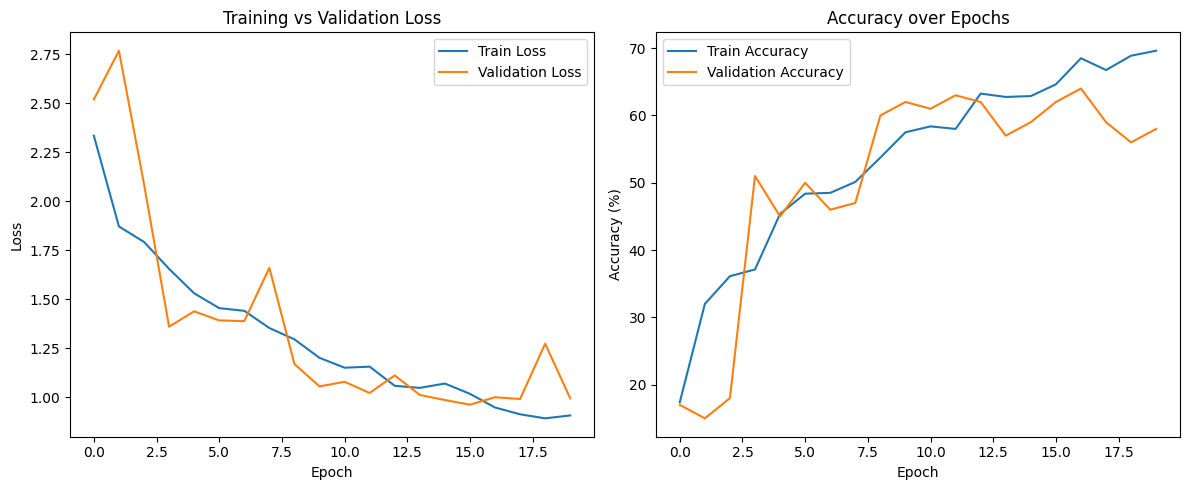

In [ ]:

from matplotlib import pyplot as plt

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 📉 Loss plot
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 📈 Accuracy plot
axes[1].plot(train_acc, label="Train Accuracy")
axes[1].plot(val_acc, label="Validation Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 📊 Results and Analysis

The training curves indicate that the model learns effectively, with training loss steadily decreasing and training accuracy improving from approximately **17% to ~70%** over the course of training.

Validation performance also improves during the initial epochs, reaching a peak accuracy of around **64%** at approximately **epoch 17**. This suggests that the model is able to generalize reasonably well to unseen data in the early stages of training.

However, beyond this point, validation accuracy begins to decline while training accuracy continues to increase. Additionally, validation loss starts to fluctuate. This indicates the onset of **overfitting**, where the model begins to memorize training data rather than improving generalization.

The gap between training accuracy (**~**70%) and validation accuracy (~60-64%) remains relatively moderate, suggesting that overfitting is present but not severe. This behavior is likely influenced by the relatively small dataset size.

### 🔑 Key Observations
- The model successfully learns meaningful patterns from the data.
- Best performance is achieved around **epoch 17**.
- Overfitting begins after this point.
- Dataset size is a limiting factor for further performance improvement.

### ✅ Conclusion
The model achieves a reasonable balance between learning and generalization, with a peak validation accuracy of **~64%**. Implementing techniques such as **early stopping**, **data augmentation**, or **regularization** could further improve performance.

In [ ]:
model.load_state_dict(torch.load("best_model.pth")) # Load the best model
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        loss = loss_function(outputs, y)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

test_loss /= len(test_loader)
accuracy = 100 * correct / total

print("Test Loss:", test_loss)
print("Test Accuracy:", accuracy, "%")

Test Loss: 1.089916005730629
Test Accuracy: 66.0 %
